In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e
orbs = ('s', 'p', 'd', 'f')
colours = ('orange', 'green', 'red', 'blue')


C:\Users\Tommy\AppData\Local\Temp\ipykernel_20724\566063401.py:71: RuntimeWarning: divide by zero encountered in log10
  cmap = ax.imshow(np.log10(abs(Z)), cmap='Greens', extent=(-0.5, n_max-.5, min_dif-.5, max_dif+.5), origin='lower')


(array([1, 3, 4]),)


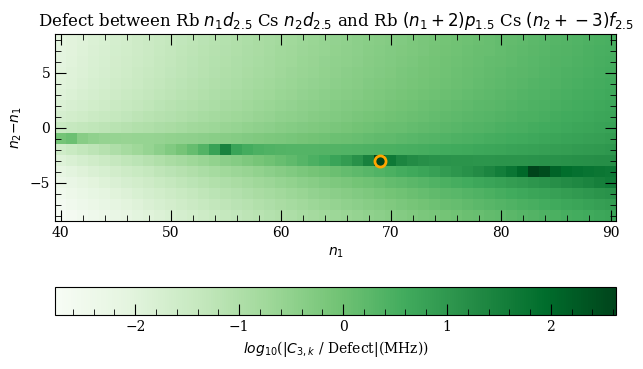

In [73]:
from pairinteraction.visualization.colormaps import alphamagma
atom1, atom2 = 'Rb', 'Cs'

l1, l2 = 2, 2
j1, j2 = 5/2, 5/2
l1_1, l2_1 = 1, 3
j1_1, j2_1 = 3/2, 5/2
min_n, max_n = 40, 91
change1, change2 = 2, -3



plot_n1s=[]
plot_n2s=[]
# fig, ax = plt.subplots()
# ax.set_aspect('equal', adjustable='box')
c3k_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\strip C3s\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {change1} {change2} ns 4091.csv'
if os.path.exists(c3k_path):
    c3k_data = pd.read_csv(c3k_path)

n1s = c3k_data['n1s'].to_numpy()
n2s = c3k_data['n2s'].to_numpy()
c3ks = c3k_data['c3k'].to_numpy()

red_n1s = np.arange(min(n1s), max(n1s)+1)
red_n2s = np.arange(min(n2s), max(n2s)+1)

# print(n1s)


min_n = 30
max_n = 120
max_dif = 8
min_dif = -8
n_max = max_n + max_dif
n_min = min_n + min_dif

Z_c3k = np.zeros((max_dif-min_dif+1, n_max))
Z_def = np.zeros((max_dif-min_dif+1, n_max))


difs = np.arange(-8, 9)
for c3k, n1, n2 in zip(c3ks, n1s, n2s):
    if abs(n2 - n1) > 8:
        continue
    Z_c3k[list(difs).index(n2 - n1), n1] = c3k


for dif in difs:
    defect_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\defects\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {dif} {change1} {change2}.csv'
    data = pd.read_csv(defect_path)
    defects = data['defect'].to_numpy()
    n1_0s = data['n'].to_numpy()
    for n, defect in zip(n1_0s, defects):
        Z_def[list(difs).index(dif), n] = 1/defect


Z = np.multiply(Z_c3k, Z_def)

c3kXdefectFigure_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\C3kXdefect\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}'
if not os.path.exists(c3kXdefectFigure_path):
    os.makedirs(c3kXdefectFigure_path)
# fig.savefig(c3kFigure_path + f'\\{j1_1}, {j2_1} {change1} {change2} ns {min_n}{max_n}.png')

plot_n1s=[]
plot_n2s=[]
fig, ax = plt.subplots(nrows=1)

# ax[0].set_aspect('equal', adjustable='box')

cmap = ax.imshow(np.log10(abs(Z)), cmap='Greens', extent=(-0.5, n_max-.5, min_dif-.5, max_dif+.5), origin='lower')

col = 0

path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\channels\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}.csv'
if os.path.exists(path):
    df = pd.read_csv(path)
    print(np.where(df['change2'] == change2))
    inds1 = np.where(df['change1'] == change1)
    inds2 = np.where(df['change2'] == change2)
    indsj1 = np.where(df['j1_1'] == j1_1)
    indsj2 = np.where(df['j2_1'] == j2_1)
    indsj = np.intersect1d(indsj1, indsj2)
    indsc = np.intersect1d(inds1, inds2)
    inds = np.intersect1d(indsc, indsj)
    plot_n1s = df['n1_0'][inds].to_numpy()
    plot_n2s = df['n2_0'][inds].to_numpy()
    ax.plot(plot_n1s, plot_n2s - plot_n1s, 'o', markerfacecolor='none', markersize=8, color=colours[col], markeredgewidth=2, label = f'{orbs[l1_1]} {orbs[l2_1]}')
    col+=1



C6Data_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\C6 grids\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]} j1j2({j1},{j2}).csv'

if os.path.exists(C6Data_path):
    data = pd.read_csv(C6Data_path)
    ax.set_position((.1, .2, .8, .5))
    ax1 = fig.add_axes((.12, .1,.85, .1))
    inds = np.where((data['n1'] == data['n2']))


    ax1.plot(data['n1'].to_numpy()[inds], data['C6'].to_numpy()[inds])
    ax1.set_ylabel(r'$C_6$ (GHz $\mu m^6$)')
    ax1.set_xlim(39.5, 90.5)

# plt.legend()

# fig.subplots_adjust(right=0.8)
# cbar_ax = fig.add_axes([0.95, 0.15, 0.03, 0.7])
cbar = plt.colorbar(cmap, label=r'$log_{10}$(|$C_{3,k}$ / Defect|(MHz))', location='bottom')
# cbar.set_ticks(np.arange(-2,6))
plt.xlabel(r'$n_1$')
ax.set_ylabel(r'$n_2 \minus n_1$')
# plt.ylim(n_min, n_max)
ax.set_xlim(39.5, 90.5)
plt.title(rf'Defect between {atom1} $n_1{orbs[l1]}_{{{j1}}}$ {atom2} $n_2{orbs[l2]}_{{{j2}}}$ and {atom1} $(n_1+{change1}){orbs[l1_1]}_{{{j1_1}}}$ {atom2} $(n_2+{change2}){orbs[l2_1]}_{{{j2_1}}}$')
fig.tight_layout()
plt.show()

if not os.path.exists(c3kXdefectFigure_path + '\\change1 change2 difRange.txt'):
    with open(c3kXdefectFigure_path + '\\change1 change2 difRange.txt', "w") as file:
        file.write("")
fig.savefig(c3kXdefectFigure_path + f'\\j0s({j1},{j2}) j1s({j1_1},{j2_1}) {change1} {change2} difs({difs[0]},{difs[-1]}).png')